In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout, BatchNormalization, Activation

In [6]:


# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")

# 2. Normalize the image data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Reshape the training and test image data
# Images are 28x28, so they should become a 784-element array
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))
print(f"Reshaped x_train shape: {x_train.shape}")

# 4. Convert the integer labels to one-hot encoded vectors
num_classes = 10 # MNIST has digits 0-9
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(f"One-hot encoded y_train shape: {y_train.shape}")

Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Reshaped x_train shape: (60000, 784)
One-hot encoded y_train shape: (60000, 10)


In [7]:


# 1. Define the baseline model
baseline_model = Sequential([
    Input(shape=(784,)), # Use Input layer to define input shape
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# 3. Train the model and store the history
history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Baseline model training complete.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8384 - loss: 0.5835 - val_accuracy: 0.9512 - val_loss: 0.1667
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9578 - loss: 0.1443 - val_accuracy: 0.9638 - val_loss: 0.1187
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9725 - loss: 0.0928 - val_accuracy: 0.9699 - val_loss: 0.0936
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9794 - loss: 0.0706 - val_accuracy: 0.9741 - val_loss: 0.0830
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9829 - loss: 0.0542 - val_accuracy: 0.9748 - val_loss: 0.0771
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9872 - loss: 0.0417 - val_accuracy: 0.9773 - val_loss: 0.0729
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9905 - loss: 0.0330 - val_accuracy: 0.9746 - val_loss: 0.0797
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9917 - loss: 0.0268 - val_accuracy: 0.

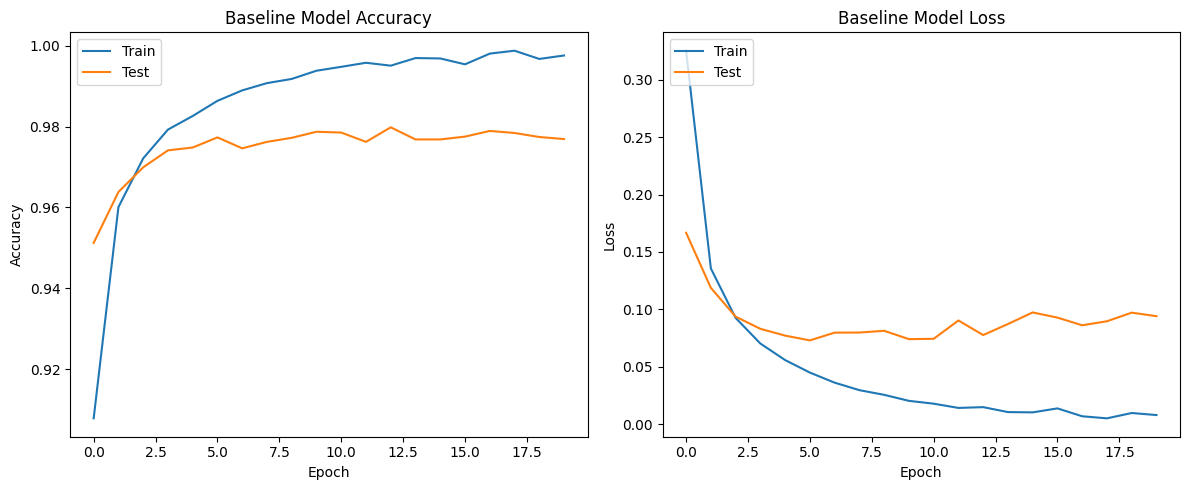

Baseline model performance curves plotted.


In [12]:
# Plotting performance curves for the baseline model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'])
plt.plot(history_baseline.history['val_accuracy'])
plt.title('Baseline Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])
plt.title('Baseline Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Baseline model performance curves plotted.")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6850 - loss: 0.9616 - val_accuracy: 0.9388 - val_loss: 0.2018
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9104 - loss: 0.3092 - val_accuracy: 0.9546 - val_loss: 0.1490
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9331 - loss: 0.2363 - val_accuracy: 0.9614 - val_loss: 0.1264
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9421 - loss: 0.2029 - val_accuracy: 0.9656 - val_loss: 0.1120
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9503 - loss: 0.1779 - val_accuracy: 0.9694 - val_loss: 0.1049
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9544 - loss: 0.1569 - val_accuracy: 0.9719 - val_loss: 0.0977
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9571 - loss: 0.1471 - val_accuracy: 0.9726 - val_loss: 0.0927
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9575 - loss: 0.1451 - val_accuracy: 0.

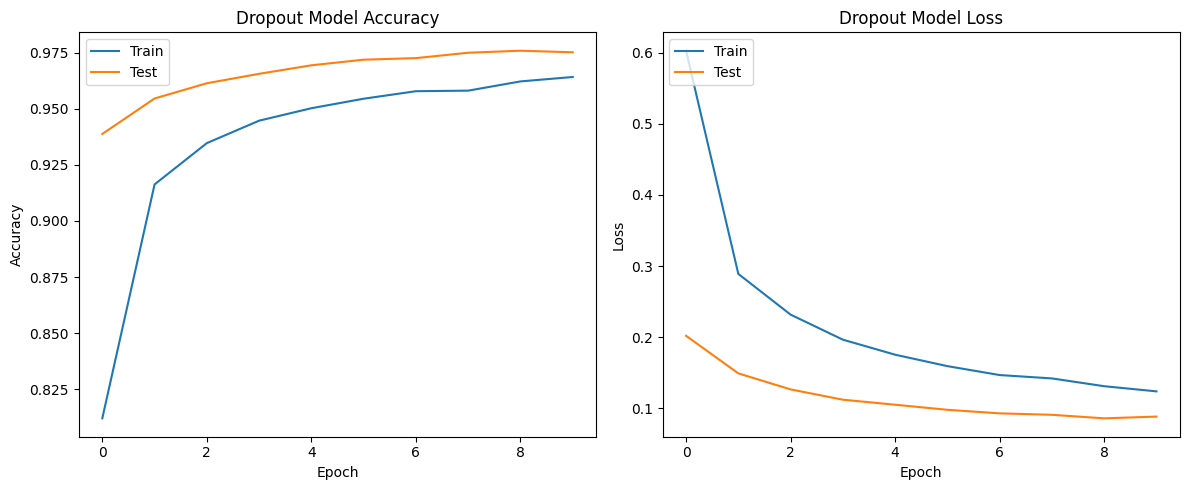

Dropout model performance curves plotted.


In [17]:
# 1. Define the model with Dropout layers
dropout_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

# 3. Train the model and store the history
history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Dropout model training complete.")


# Plotting performance curves for the dropout model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['accuracy'])
plt.plot(history_dropout.history['val_accuracy'])
plt.title('Dropout Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'])
plt.plot(history_dropout.history['val_loss'])
plt.title('Dropout Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Dropout model performance curves plotted.")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8214 - loss: 0.8447 - val_accuracy: 0.9502 - val_loss: 0.3315
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9528 - loss: 0.3162 - val_accuracy: 0.9631 - val_loss: 0.2648
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9643 - loss: 0.2537 - val_accuracy: 0.9679 - val_loss: 0.2253
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9707 - loss: 0.2172 - val_accuracy: 0.9700 - val_loss: 0.2092
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9735 - loss: 0.1988 - val_accuracy: 0.9733 - val_loss: 0.1924
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9766 - loss: 0.1819 - val_accuracy: 0.9703 - val_loss: 0.1915
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9768 - loss: 0.1733 - val_accuracy: 0.9724 - val_loss: 0.1820
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9795 - loss: 0.1628 - val_accuracy: 0.

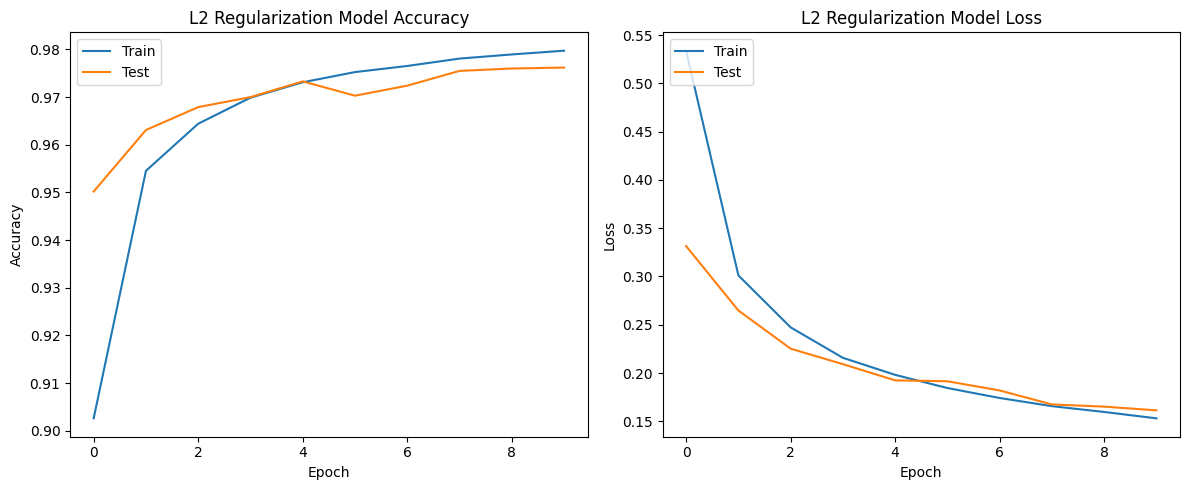

L2 Regularization model performance curves plotted.


In [18]:
# 1. Define the model with L2 regularization layers
l2_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),  # Added L2 regularization
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
l2_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

l2_model.summary()

# 3. Train the model and store the history
history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("L2 Regularization model training complete.")

import matplotlib.pyplot as plt

# Plotting performance curves for the L2 regularization model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_l2.history['accuracy'])
plt.plot(history_l2.history['val_accuracy'])
plt.title('L2 Regularization Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_l2.history['loss'])
plt.plot(history_l2.history['val_loss'])
plt.title('L2 Regularization Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("L2 Regularization model performance curves plotted.")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       100,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,962 (429.54 KB)

 Trainable params: 109,578 (428.04 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8422 - loss: 0.5607 - val_accuracy: 0.9615 - val_loss: 0.1339
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9699 - loss: 0.1071 - val_accuracy: 0.9708 - val_loss: 0.0958
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9803 - loss: 0.0672 - val_accuracy: 0.9746 - val_loss: 0.0802
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9872 - loss: 0.0457 - val_accuracy: 0.9728 - val_loss: 0.0844
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9907 - loss: 0.0341 - val_accuracy: 0.9761 - val_loss: 0.0744
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9912 - loss: 0.0281 - val_accuracy: 0.9779 - val_loss: 0.0714
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9936 - loss: 0.0219 - val_accuracy: 0.9757 - val_loss: 0.0784
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9937 - loss: 0.0200 - val_accuracy: 0.

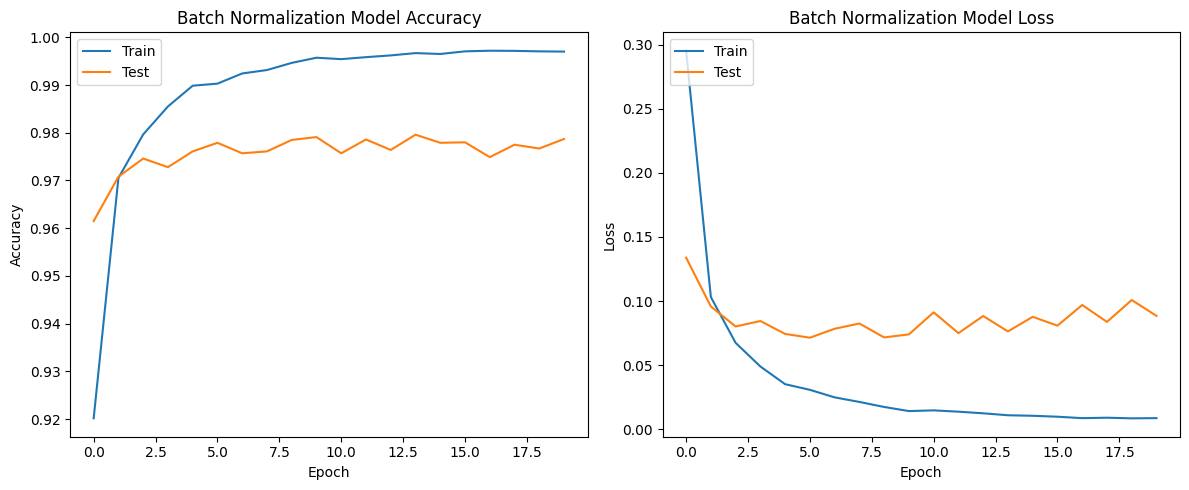

Batch Normalization model performance curves plotted.


In [15]:
# 1. Define the model with Batch Normalization layers
bn_model = Sequential([
    Input(shape=(784,)),
    Dense(128, use_bias=False), # Use_bias=False when followed by BatchNormalization
    BatchNormalization(),
    Activation('relu'),
    Dense(64, use_bias=False), # Use_bias=False when followed by BatchNormalization
    BatchNormalization(),
    Activation('relu'),
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bn_model.summary()

# 3. Train the model and store the history
history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Batch Normalization model training complete.")


# Plotting performance curves for the Batch Normalization model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_bn.history['accuracy'])
plt.plot(history_bn.history['val_accuracy'])
plt.title('Batch Normalization Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_bn.history['loss'])
plt.plot(history_bn.history['val_loss'])
plt.title('Batch Normalization Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Batch Normalization model performance curves plotted.")

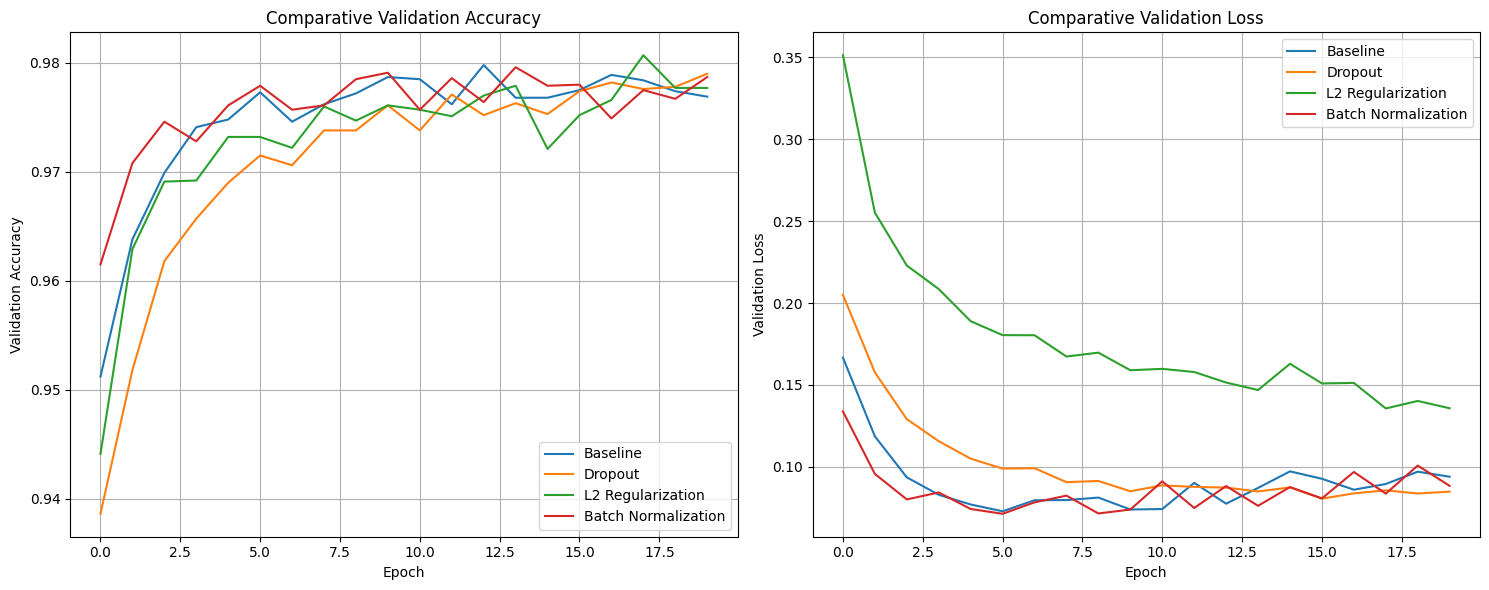

Comparative performance curves plotted.


In [16]:
plt.figure(figsize=(15, 6))

# Subplot 1: Comparative Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2 Regularization')
plt.plot(history_bn.history['val_accuracy'], label='Batch Normalization')
plt.title('Comparative Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Subplot 2: Comparative Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2 Regularization')
plt.plot(history_bn.history['val_loss'], label='Batch Normalization')
plt.title('Comparative Validation Loss')
plt.ylabel('Validation Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Comparative performance curves plotted.")